# Import general libraries


In [5]:
# Import libraries
import sys
import os
import json 
import pandas as pd
import matplotlib.pylab as plt
import h5py
import numpy as np


In [6]:
print("Current directory :", os.getcwd())
test_directory = os.getcwd()
os.chdir("./..")
print("Changed to directory :", os.getcwd())
main_directory = os.getcwd()

Current directory : /Users/alaukiksaxena/Calculations/20241024_Nikita/CompositionSpaceNFDI
Changed to directory : /Users/alaukiksaxena/Calculations/20241024_Nikita


# Import tools

In [7]:
from compositionspace.datautils import DataPreparation
from compositionspace.segmentation import CompositionClustering
from compositionspace.postprocessing import DataPostprocess

### Read the inputs (experiment parameters)

# 1. Pre-processing

* Reading the reconstruction data (spatial coordintes of ions)(.APT, .POS, .csv)
* Reading range file (.rrng)
* concacting chemical species to each ion using the mass to charge ratio ranges from the range file(.rrng).
* Spatially discretize the reconstructed data into slices. (Especially useful if the original data is very large)
* Voxelize each slice
* Calculate the composition of each voxel( in atomic fraction)

A. Input defined in "experiment_params.yaml" 
*  **input_path: tests/datapath** 
*  **n_big_slices: 10**: Number of slices perpendicular to axis of reconstructed data
*  **voxel_size: 2**: Voxel size(cube) in nm
*  input path must contain .APT(or.POS, .csv) and .rrng

B. Output defined in "experiment_params.yaml"
*  **output_path: output**
*  get_big_slices>>(.h5) : 
    1. Atomic coordinates in each slice (x,y,z)
    2. Chemical identities per atom (Da, spec)
    3. Atributes : coloumns, mass to charge states ,type of chemical species
* get_voxels>>(.h5):
    1. Atomic coordinates in each voxel(x,y,z)
    2. Chemical identities per atom (spec)
    3. Atributes : coloumns, type of chemical species, Total number of voxels
* calculate_voxel_composition>>(.h5):
    1. Coordinates of each voxel centroid (x,y,z)
    2. atomic fraction of each chemical species 



In [4]:
data = DataPreparation(test_directory + "/experiment_params.yaml")
data.get_big_slices()
data.get_voxels()
data.calculate_voxel_composition()

Reading files:   0%|          | 0/3 [00:00<?, ?it/s]

Done, reading *.APT file


Creating chunks:   0%|          | 0/10 [00:00<?, ?it/s]

Getting Voxels:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating voxel composition:   0%|          | 0/965655 [00:00<?, ?it/s]

In [5]:
data.chunk_files

['output/file_center2_R5076_87726_v1_r27 AN_20240321 - Top Level ROI_apt_large_chunks_arr.h5']

In [6]:
data.voxel_files

['output/file_center2_R5076_87726_v1_r27 AN_20240321 - Top Level ROI_apt_small_chunks_arr.h5']

In [7]:
data.voxel_ratio_file

'output/output_vox_ratio_composition.h5'

# 2. Clustering in composition space

* Calculate contribution of each species towards variance in composition (using PCA)(Also helps to guage importance of a certain chemical species in the data)

* For a certain clustering algorithm perform minimisation of BIC and AIC (to guage model complexity vs information) (to get the optimum number of clusters)
* Use Gaussian mixture models (GMM) to perform clustering in composition space with the number of clusters from the previous step. 

A. Input defined in "experiment_params.yaml" 
*  **bics_clusters: 10**: Number of clusters for which bics/aics is calculated
*  **n_phases: 2**: number of phases based on bics elbow critieria
*  **GaussianMixture: n_components:2 max_iter: 100000 ** : GMM is used for clustering with 2 components(n_components), The number of EM iterations to perform (max_iter) 

B. Output defined in "experiment_params.yaml"
*  **output_path: output**

*  get_PCA_cumsum>>(.jpg) : 
    * Explained variance vs Dimensions

* get_bics_minimization>>(.jpg):
    * Bic/Aic vs number of clusters
* get_composition_clusters>>(.h5):
    * Voxel positions and compostion (per phase)
* generate_plots>>(.vtu):
    * 3D Plots of voxel position per phase in real space 




965655
['0', '1', '2', '3', '4', '0_atoms', '1_atoms', '2_atoms', '3_atoms', '4_atoms', 'Total_no', 'vox']


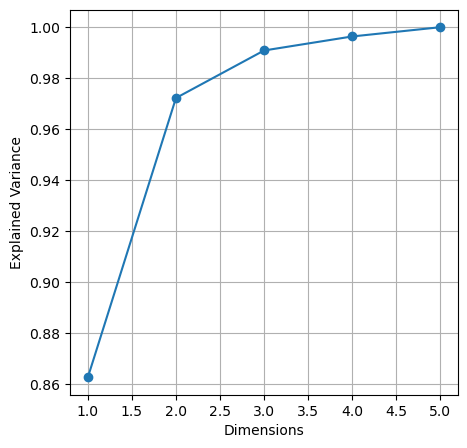

In [8]:
comps = CompositionClustering(test_directory + "/experiment_params.yaml")
res = comps.get_PCA_cumsum(data.voxel_ratio_file, data.voxel_files[0])

Clustering:   0%|          | 0/9 [00:00<?, ?it/s]

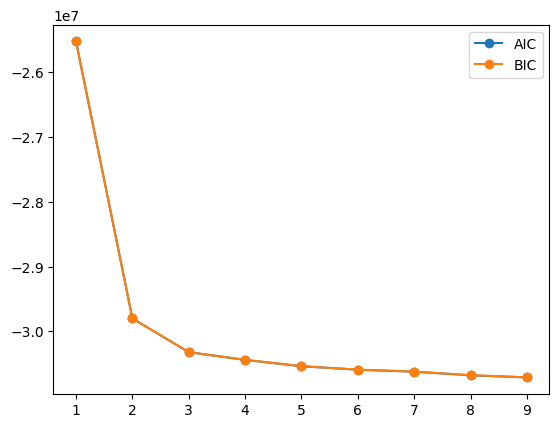

In [9]:
res = comps.get_bics_minimization(data.voxel_ratio_file, data.voxel_files[0])

In [10]:
initial_guess_phases = 3
plot=True
print_importance= True
modified_comp_analysis=True
n_trunc_spec=3

In [11]:
"""sorted_chem_idx = comps.auto_phase_assign(
    data.chunk_files[0], 
    data.voxel_ratio_file,
    initial_guess_phases,
    plot=plot,                     # Keyword argument
    print_importance=print_importance, # Keyword argument
    modified_comp_analysis=modified_comp_analysis, # Optional keyword argument
    n_trunc_spec=n_trunc_spec      # Optional keyword argument
)"""

'sorted_chem_idx = comps.auto_phase_assign(\n    data.chunk_files[0], \n    data.voxel_ratio_file,\n    initial_guess_phases,\n    plot=plot,                     # Keyword argument\n    print_importance=print_importance, # Keyword argument\n    modified_comp_analysis=modified_comp_analysis, # Optional keyword argument\n    n_trunc_spec=n_trunc_spec      # Optional keyword argument\n)'

In [9]:
comps.get_composition_clusters(data.voxel_ratio_file, data.voxel_files[0])

In [10]:
comps.generate_plots()

# 3. Postprocessing
* Clean the precipitates/chemical domains of diffrent phases from the noisy voxels
* Segment out each precipitate in 3D 

A. Input defined in "experiment_params.yaml" 

*  **DBScan: eps: 3 min_samples: 5** : DBScan is used for clustering with core radius(eps) and minmum data points in the radius as  min_samples

B. Output defined in "experiment_params.yaml"
*  **output_path: output**

*  DBSCAN_clustering>>(.jpg, .vtu, .h5) : 
    1. Clustering histogram for a given value of eps and min_samples (.jpg)
    2. Different precipitates voxels centroids (x,y,z) are stored (.h5)
    3. Precipitates are visualised using parview (.vtu)



In [13]:
pdata = DataPostprocess(test_directory + "/experiment_params.yaml")

  0%|          | 0/58 [00:00<?, ?it/s]

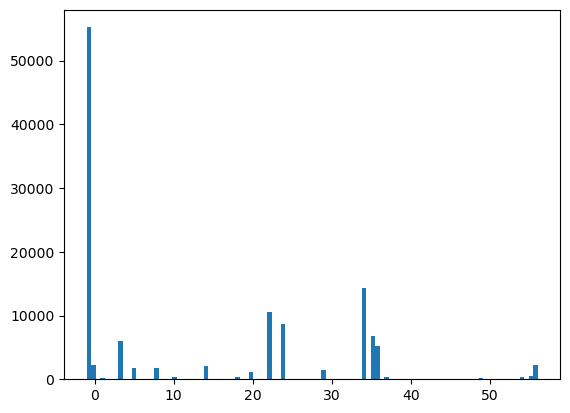

In [23]:
pdata.DBSCAN_clustering(comps.voxel_centroid_output_file, cluster_id = 0,
                        plot=True, plot3d=True, save=True)

# 3. Composition Analysis


In [15]:
data.voxel_ratio_file

'output/output_vox_ratio_composition.h5'

In [12]:
with h5py.File(main_directory + "/"+  "CompositionSpaceNFDI/output/output_vox_ratio_composition.h5", "r") as hdfr:  # data.voxel_ratio_file
    ratios = np.array(hdfr.get("vox_ratios"))


In [13]:
ratios

array([[5.26881720e-01, 8.60215054e-02, 2.36559140e-01, ...,
        1.00000000e+00, 9.30000000e+01, 0.00000000e+00],
       [5.94339623e-01, 3.77358491e-02, 2.50000000e-01, ...,
        3.00000000e+00, 2.12000000e+02, 1.00000000e+00],
       [6.33699634e-01, 3.29670330e-02, 2.56410256e-01, ...,
        1.00000000e+00, 2.73000000e+02, 2.00000000e+00],
       ...,
       [6.40000000e-01, 0.00000000e+00, 2.80000000e-01, ...,
        0.00000000e+00, 2.50000000e+01, 9.65652000e+05],
       [6.04166667e-01, 2.08333333e-02, 3.33333333e-01, ...,
        0.00000000e+00, 4.80000000e+01, 9.65653000e+05],
       [6.88888889e-01, 2.22222222e-02, 2.66666667e-01, ...,
        0.00000000e+00, 4.50000000e+01, 9.65654000e+05]])

In [57]:
data.chemical_species

AttributeError: 'int' object has no attribute 'chemical_species'

In [33]:
def variation(x_frac, n_total, eff):
    var = x_frac*(1-x_frac)*(1-eff)/n_total
    return(var)

def mean_SD_calculator(Df, var_cal = False):
    
    atoms_spec = []
    for i in range(5):
        atoms_spec.append(np.sum(Df["{}_atoms".format(int(i))].values))
    Total_atoms = np.sum(Df["Total_no"].values)
    atoms_spec = np.array(atoms_spec)
    mean = atoms_spec/Total_atoms
    if var_cal == True:
        sd = []

        for j in range(5):
            sd.append(variation(mean[j], Total_atoms, 0.8))
        return mean, sd     
    else:
        return mean
    


In [34]:
mean_arr = False
divide_equal = True
Samples = 1500
chemical_species = ['Co:1', 'Cu:1', 'Fe:1', 'Sm:1', 'Zr:1'] #data.chemical_species # 

phase_id = 2

#data.voxel_ratio_file 
with h5py.File(main_directory + "/"+ "CompositionSpaceNFDI/output/output_vox_ratio_composition.h5", "r") as hdfr:
    ratios = np.array(hdfr.get("vox_ratios"))
    col_ratio = list(list(hdfr.attrs.values())[0])
    vox_ratio_Df = pd.DataFrame(data= ratios, columns= col_ratio)
    


with h5py.File(main_directory + "/"+ f"CompositionSpaceNFDI/output/Output_DBSCAN_segmentation_phase{phase_id}.h5" , "r") as hdfr:
    #ratios = np.array(hdfr.get("vox_ratios"))
    group = hdfr.get(f"{phase_id}")
    keys = list(group.items())

    df_lst = []
    
    for i in range(len(keys)):
        k =np.array(group["{}".format(int(i))])

        col = list(list(hdfr[f"{phase_id}"].attrs.values())[0])
        Df_combined = pd.DataFrame(data= k, columns= col)
        #print(len(Df_combined))
        df_lst.append(Df_combined)   
        #print(Df_combined)  

    len_lst = []
    for i in df_lst:
        len_lst.append(len(i))

    df_lst_corr = []
    for data in range(len(df_lst)):

        arr_files = df_lst[data].values[:,-1]

        vox_ratio_preci = vox_ratio_Df[vox_ratio_Df['vox'].isin(arr_files)]
        df_lst_corr.append(vox_ratio_preci)


        if divide_equal == True:
        
            comb =pd.concat(df_lst_corr)
            ##print(comb.columns)
            #shuffled = comb.sample(frac=1)
            shuffled = comb
            NoVox = len(shuffled)/Samples
            df_lst_corr = np.array_split(shuffled, int(round(NoVox)))
            #print(df_lst_corr)

    
    
    
        atom_frac_lst = []
        for Df_ID in range(len(df_lst_corr)):
            #print(Df_ID)
            atom_frac_lst.append(mean_SD_calculator(df_lst_corr[Df_ID]))
        atom_frac_arr = np.array(atom_frac_lst)
        #print(atom_frac_arr)
        
        if np.isnan(atom_frac_arr).any() == True:
            #print("hi")
            atom_frac_arr =  np.delete(atom_frac_arr, np.argwhere(np.isnan(atom_frac_arr))[0,0], axis = 0)
            
        if mean_arr == True:
            #return atom_frac_arr#,df_lst_corr
            print(mean_arr)
            
        else:
            mean = []
            std = []
            for spec in range(5):
                mean.append(np.mean(atom_frac_arr[:,spec]))
                std.append(np.std(atom_frac_arr[:,spec]))

       # return mean, std 
        




In [35]:
phase2_vox = sum(len_lst)

In [32]:
phase0_vox = sum(len_lst)

In [30]:
phase1_vox = sum(len_lst)

In [38]:
total_vox = sum([phase0_vox,phase1_vox,phase2_vox])

In [41]:
ph0 = phase0_vox/total_vox
ph1 = phase1_vox/total_vox
ph2 = phase2_vox/total_vox

In [45]:
sum([ph0, ph1,ph2])

1.0

In [23]:
np.array(mean)*100


array([59.53952949,  4.97211915, 16.54983261, 10.41587043,  8.52264832])

In [24]:
np.array(std)*100

array([1.25504965, 0.50216293, 1.10290882, 0.71573446, 0.90731568])

In [ ]:
['Co:1', 'Cu:1', 'Fe:1', 'Sm:1', 'Zr:1'] #data.chemical_species # 


In [ ]:
# phase2 or 2:17:

array([59.33951227,  2.3684634 , 26.55087786, 11.23747233,  0.50367414])
array([0.1659422 , 0.15678254, 0.15372183, 0.11252625, 0.0723983 ])

#phase1 pr Z phase
array([59.53952949,  4.97211915, 16.54983261, 10.41587043,  8.52264832])
array([1.25504965, 0.50216293, 1.10290882, 0.71573446, 0.90731568])
#Phase0 or 1:5
array([49.905629  , 17.64582935, 18.35004994, 13.42636055,  0.67213116])
array([2.32875052, 3.47802165, 1.77037679, 0.71509998, 0.1985229 ])



Text(0, 0.5, 'Cu:1')

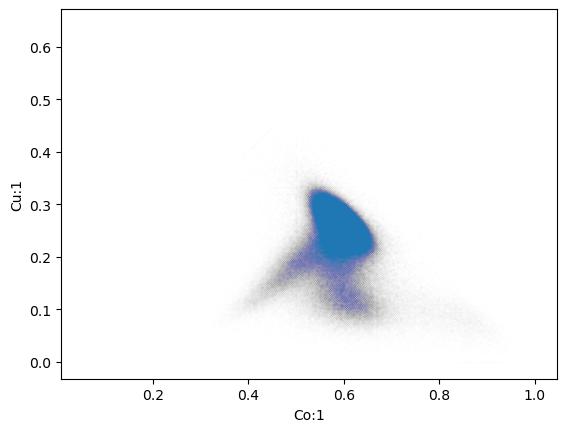

In [31]:
#Plot the two chemical species with highest relative importance
plt.scatter(ratios[:,0],ratios[:,2] ,s =0.000005)

plt.xlabel(data.chemical_species[0])
plt.ylabel(data.chemical_species[1])


Text(0, 0.5, 'Voxel frequency')

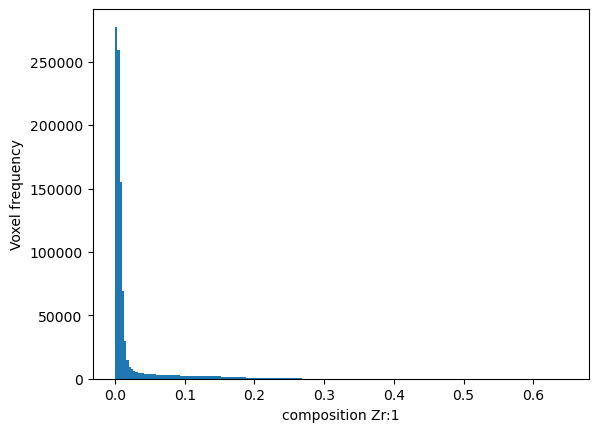

In [23]:
# voxel frequency plot for the chemical species 
# with highest relative importance

plt.hist(ratios[:,sorted_chem_idx[0]], bins = 200);
plt.xlabel(f"composition {data.chemical_species[sorted_chem_idx[0]]}")
plt.ylabel("Voxel frequency")
